# Alcatraz

Define bandages, replay and import colored scrambles, restore the shape, inspect its loop generators, and compute the exact colored-state count. For this tractable puzzle, also find shortest colored solutions and explore the complete colored distance profile.

Use the **v2/.venv** Python environment in VS Code's **Select Kernel** menu. Run the cells from top to bottom, then edit the bandage list or scramble and rerun the following cells.

Group analysis needs the optional **GAP** executable on `PATH`. Set `GAP_EXECUTABLE` below if your GAP launcher is elsewhere. Loop extraction and direct colored solving work without GAP.


In [1]:
import sys
from collections import Counter
from html import escape
from pathlib import Path
from tempfile import TemporaryDirectory

import bce_v2 as c
import matplotlib.pyplot as plt
from IPython.display import HTML, display

%matplotlib inline
GAP_EXECUTABLE = "gap"
print("Python kernel:", sys.executable)


Python kernel: /home/ladislav/prj/nonvl/bandaged-cube-explorer/v2/.venv/bin/python


## Define the puzzle

Equal positive labels fuse cells into one block. Each zero is an independent singleton. The named cell constants, such as `c.F` and `c.DF`, index this 27-cell grid.

Edit the list to experiment with other connected bandages. For the recorded fixture, you can also use `c.fixture("Alcatraz")`.


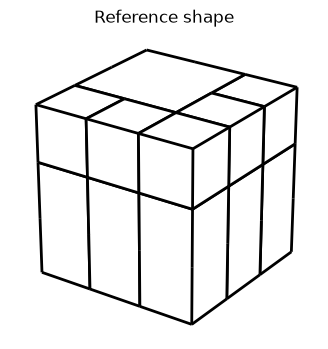

In [4]:
alcatraz = [
      6, 6, 0,
     6, 6, 0,
    0, 0, 0,
      7, 7, 5,
     7, 7, 4,
    1, 2, 3,
      7, 7, 5,
     7, 7, 4,
    1, 2, 3,
]

initial = c.Shape(alcatraz)
solved = c.State(initial)

figure = c.draw_cubes(initial)
figure.axes[0].set_title("Reference shape")
plt.show()


## Replay a scramble

Change the move string below. All moves use standard Singmaster notation: `U R F D L B`, with optional `2` or `'`. A blocked move raises `c.BlockedMoveError`.

`State` retains corner and edge identities and orientations. Applying moves returns a new state.


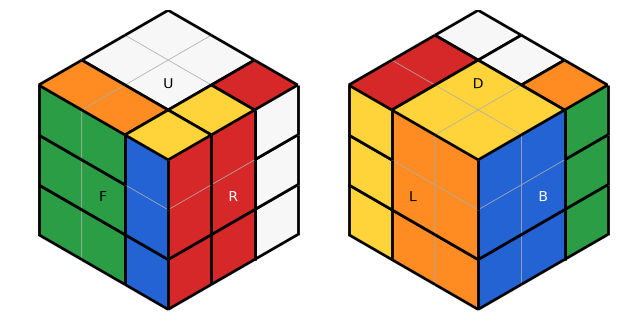

{'scramble': 'F R2',
 'legal_moves': ['R', 'R2', "R'", 'F', 'F2', "F'"],
 'colored_solved': False,
 'corners': [7, 5, 2, 0, 3, 4, 6, 1],
 'twists': [0, 2, 0, 2, 0, 1, 0, 1],
 'edges': [4, 9, 2, 3, 0, 8, 6, 7, 11, 5, 10, 1],
 'flips': [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]}

In [5]:
moves = "F R2"
scrambled = solved.apply(moves)
c.draw_cubes(scrambled, colors=True, views=("UFR", "BLD"))
plt.show()

{
    "scramble": scrambled.scramble,
    "legal_moves": scrambled.legal_moves,
    "colored_solved": scrambled.is_solved,
    "corners": scrambled.corners,
    "twists": scrambled.twists,
    "edges": scrambled.edges,
    "flips": scrambled.flips,
}


## Explore the shape component

Exploration runs to completion by default. The graph retains distinct move actions and self-loops. The recorded Alcatraz puzzle has 1,449 shapes and 2,048 clockwise arcs in QTM.


In [6]:
graph = c.explore(initial, metric="QTM")
assert graph.complete

{
    "shapes": len(graph),
    "clockwise_arcs": len(graph.arcs),
    "metric": graph.metric,
    "complete": graph.complete,
}


{'shapes': 1449, 'clockwise_arcs': 2048, 'metric': 'QTM', 'complete': True}

## Restore the bandage shape

A shortest shape solution restores geometry. Whether the colors are solved is a separate question, checked by `State.is_solved`. The direct colored search below targets the full solved state; the loop analysis describes all colored states above the restored shape.


In [7]:
solution = graph.shortest_path(scrambled, initial)
restored = scrambled.apply(solution)
assert restored.shape == initial

{
    "shape_solution": solution,
    "quarter_turns": graph.distances(initial)[graph.vertex_id(scrambled)],
    "shape_restored": restored.shape == initial,
    "colors_solved": restored.is_solved,
}


{'shape_solution': "R R F'",
 'quarter_turns': 3,
 'shape_restored': True,
 'colors_solved': True}

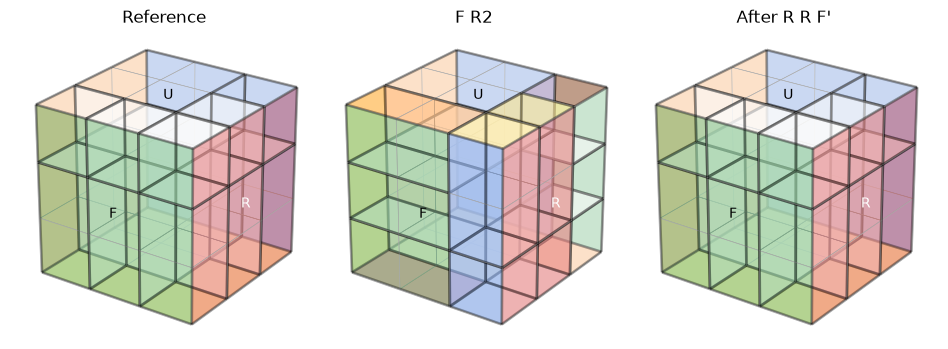

In [8]:
figure = c.draw_cubes([solved, scrambled, restored], colors=True, alpha=0.35)
for axis, title in zip(figure.axes, ["Reference", moves, f"After {solution or 'no moves'}"]):
    axis.set_title(title)
plt.show()


## Compare move metrics

QTM counts half turns as two quarter turns. HTM counts every face turn, including a half turn, as one move. Pass shapes or states between graphs; vertex IDs belong to an individual exploration.


In [9]:
htm_graph = c.explore(initial, metric="HTM")
htm_solution = htm_graph.shortest_path(scrambled, initial)
assert scrambled.apply(htm_solution).shape == initial

{
    "QTM": {
        "solution": solution,
        "cost": graph.distances(initial)[graph.vertex_id(scrambled)],
    },
    "HTM": {
        "solution": htm_solution,
        "cost": htm_graph.distances(initial)[htm_graph.vertex_id(scrambled)],
    },
}


{'QTM': {'solution': "R R F'", 'cost': 3},
 'HTM': {'solution': "R2 F'", 'cost': 2}}

## Shape loops and exact colored-state count

Reuse the complete shape graph. A spanning tree supplies root-to-shape transports; each remaining clockwise edge supplies a legal loop back to the reference shape. There are `clockwise_arcs - shapes + 1` candidate loops. The Rust extractor removes identity actions and duplicates up to inverse while retaining executable witnesses.

GAP then removes algebraically redundant generators and computes the exact isotropy-group order without enumerating colored states. Every fixed-frame shape has the same number of reachable colored states above it, so the full count is `shape_count * group_order`. Cubie identities and orientations are retained; center spin is outside this model. This stage supplies the loop library used by the colored solver below.


In [10]:
loops = graph.isotropy_loops()
assert loops.root_shape == initial
assert loops.candidate_count == len(graph.arcs) - len(graph) + 1

{
    "shapes": loops.shape_count,
    "clockwise_arcs": loops.arc_count,
    "candidate_loops": loops.candidate_count,
    "nonidentity_loops": loops.nonidentity_count,
    "generators_after_identity_and_inverse_duplicate_removal": len(loops),
}


{'shapes': 1449,
 'clockwise_arcs': 2048,
 'candidate_loops': 600,
 'nonidentity_loops': 131,
 'generators_after_identity_and_inverse_duplicate_removal': 31}

In [11]:
analysis = loops.analyze(gap_executable=GAP_EXECUTABLE)
assert analysis.colored_state_count == len(graph) * analysis.group_order

{
    "GAP_version": analysis.gap_version,
    "reduced_generators": len(analysis.generators),
    "isotropy_group_order": analysis.group_order,
    "reachable_colored_states": analysis.colored_state_count,
}


{'GAP_version': '4.12.1',
 'reduced_generators': 5,
 'isotropy_group_order': 324,
 'reachable_colored_states': 469476}

## Reference blocks and orientation legend

The inventory is anchored to `loops.root_shape`, including when loops are
extracted at a different graph root. Member-cell names identify physical blocks
and the reference slots they can occupy; normalized partition labels are not
physical identities. Singleton corners, edges, and centers retain signature
type `111`. An independent virtual core is omitted, while real core bonds are
preserved.

A decorated cycle follows the contents of each source slot. For example,
`(UFL- UFR UBR+)` moves UFL to UFR with phase `-`, UFR to UBR with phase zero,
and UBR to UFL with phase `+`. A bracketed name such as `[FL-DFL]` identifies
one fused block. The suffix belongs to that source's transition, measured in
the destination's reference frame. `(UFR-)` is an in-place twist; `()` is the
identity. Disjoint cycles describe the complete effect, and need not be
separately executable algorithms.

Read suffixes modulo the inventory's orientation order: order two uses `+`
for a flip or half turn; order three uses `+` and `-`; order four uses `+`,
`++`, and `-`. Corner `+` is the ordinary clockwise twist, and edge `+` is a
flip. Deterministic frames for larger blocks are chosen once for this reference
inventory, so phases remain consistent across generators. Bare entries have
phase zero; order-one blocks need no suffix. Unmarked center spin and virtual
core spin are not observed. See the [block-action guide](../../docs/block-actions.md)
for the exact frame construction and structured API.

These actions apply after restoring the reference partition. An off-root
scramble generally does not permute these footprints. The existing solver
still uses full sticker factorization; block quotient and kernel solving are a
subsequent delivery.


In [10]:
inventory = analysis.block_inventory
inventory_rows = []
for block in inventory.blocks:
    inventory_rows.append(
        f"<tr><td>{escape(block.name)}</td><td>{escape(block.kind)}</td>"
        f"<td>{escape(block.type or 'noncuboid')}</td>"
        f"<td>{block.orientation_order}</td></tr>"
    )
display(HTML(
    "<table><thead><tr><th>Reference block / slot</th><th>Kind</th>"
    "<th>Signature type</th><th>Orientation order</th></tr></thead><tbody>"
    + "".join(inventory_rows) + "</tbody></table>"
))


Reference block / slot,Kind,Signature type,Orientation order
221 UBL-UB-UL-U,221,221,1
Corner UBR,Corner,111,3
Edge UR,Edge,111,2
Corner UFL,Corner,111,3
Edge UF,Edge,111,2
Corner UFR,Corner,111,3
222 BL-B-L-C-DBL-DB-DL-D,222,222,1
Pair BR-DBR,Pair,Pair,1
Clock R-DR,Clock,Clock,1
Pair FL-DFL,Pair,Pair,1


## Inspect the loop generators

Each row is an original graph loop retained by GAP, with its original generator ID, replayable turn sequence, exact block action, and both move lengths. The set generates the full isotropy group; minimum generator count and shortest words are not promised.

The turn sequence combines adjacent turns of the same face, so `R R` and `R' R'` become `R2`. HTM length counts its displayed face turns, including each half turn as one. QTM length retains the quarter-turn cost of the original unsimplified witness.

The 48-point permutations map movable sticker positions to their destinations in zero-based URFDLB order, omitting centers. Replay checks verify shape restoration and the full sticker action for both the original witness and the displayed sequence.


In [12]:
generator_rows = []
for generator in analysis.generators:
    witness = generator.moves
    turn_sequence = generator.turn_sequence
    replayed = solved.apply(witness)
    displayed_replay = solved.apply(turn_sequence)
    assert replayed.shape == displayed_replay.shape == initial
    assert replayed.sticker_permutation == displayed_replay.sticker_permutation == generator.permutation
    assert generator.block_action.permutation == generator.permutation
    assert sum(2 if move.endswith("2") else 1 for move in witness.split()) == generator.qtm_length
    assert len(turn_sequence.split()) == generator.htm_length
    generator_rows.append(
        f"<tr><td>L{generator.id}</td>"
        f"<td><code>{escape(turn_sequence)}</code></td>"
        f"<td><code>{escape(generator.block_action.notation)}</code></td>"
        f"<td>{generator.qtm_length}</td><td>{generator.htm_length}</td></tr>"
    )
display(HTML(
    "<table><thead><tr><th>Generator ID</th><th>Turn sequence</th><th>Block action</th>"
    "<th>QTM length</th><th>HTM length</th></tr></thead>"
    f"<tbody>{''.join(generator_rows)}</tbody></table>"
))


Generator ID,Turn sequence,Block action,QTM length,HTM length
L142,U' R U R2 F R F2 U F U',(UBR-)(UR+)(UFL-)(UF+)(UFR-),12,10
L662,F U F' U' R' U F U' F' U' R U,(UBR- UFL+ UFR),12,12
L732,U F U' R' U' R U F' U' R' U R,(UBR- UFL UFR+),12,12
L175,R2 F2 R F2 R F2 R' F' R F',(UBR- UFL-)(UR+ UF+)(UFR-)([BR-DBR] [FL-DFL]),14,10
L285,F R2 F' R2 F R U' R2 U F' R,(UBR+ UFL+)(UR+ UF+)(UFR+)([FL-DFL] [FR-DFR]),14,11


## Inspect interesting shapes

Filter shapes using ordinary Python expressions. This selection finds shapes that allow front turns; change the expression to inspect something else. Draw a small selection for a gallery.


616 shapes permit front turns


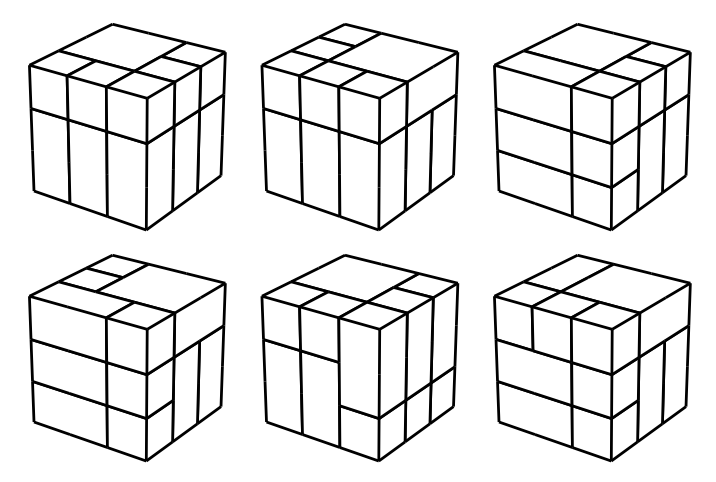

In [13]:
free_front = [value for value in graph if value.is_turnable("F")]
print(f"{len(free_front)} shapes permit front turns")

figure = c.draw_cubes(free_front[:6], ncol=3, size=3)
plt.show()


## Import a physical colored scramble

The bandage specification is always the **solved reference layout**, `initial`. The default below reimports the generated scramble. Replace `facelets` with your own six nine-character face strings to inspect and solve a physical input.

Letters name the colors of the fixed **U, R, F, D, L, B centers**; translate your physical colors to those letters. Read each face in numbered order in this unfolded net, viewed from outside:

```text
          U1 U2 U3
          U4 U5 U6
          U7 U8 U9
L1 L2 L3  F1 F2 F3  R1 R2 R3  B1 B2 B3
L4 L5 L6  F4 F5 F6  R4 R5 R6  B4 B5 B6
L7 L8 L9  F7 F8 F9  R7 R8 R9  B7 B8 B9
          D1 D2 D3
          D4 D5 D6
          D7 D8 D9
```

Keep **B at the top of U**, **F at the top of D**, and **U at the top of each side face**. The 3D preview shows opposite **UFR** and **BLD** corner views, related by a half-turn about the line through the **FL and BR edge centers**. Center letters identify the faces; thick black lines outline bandages.

For the recorded Alcatraz scramble `F R2`, the input can also be written as:

```python
facelets = (
    "UURUUDLLD"  # U
    "RRURRURRU"  # R
    "FFBFFBFFB"  # F
    "RRUDDUDDL"  # D
    "LLDLLDLLD"  # L
    "FBBFBBFBB"  # B
)
```


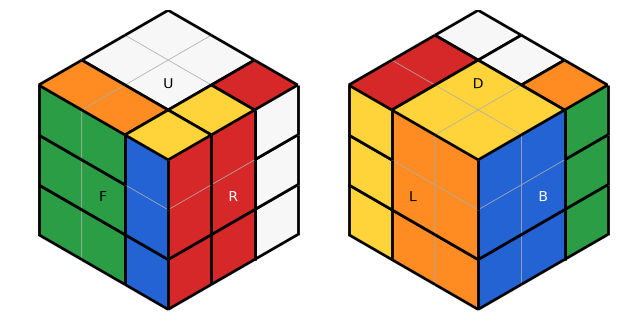

{'facelets_URFDLB': 'UURUUDLLDRRURRURRUFFBFFBFFBRRUDDUDDLLLDLLDLLDFBBFBBFBB',
 'replay_matches_import': True,
 'imported_scramble_witness': None}

In [14]:
# Reimport the current replayed scramble. Replace this with your physical
# cube's six nine-letter face strings in URFDLB order when needed.
facelets = scrambled.facelets
imported = c.State.from_facelets(facelets, initial)

c.draw_cubes(imported, colors=True, views=("UFR", "BLD"))
plt.show()

{
    "facelets_URFDLB": imported.facelets,
    "replay_matches_import": imported == scrambled,
    "imported_scramble_witness": imported.scramble,
}


## Solve the full colored scramble

Direct bidirectional BFS finds a shortest legal solution in the selected metric. HTM counts each face turn, including a half turn, as one move. The explicit state cap limits memory; a cutoff does not prove unreachability.

Use `imported` for physical facelet input or `scrambled` for a generated legal scramble. Ordinary cube and rigid-block validation alone do not establish reachability under the bandaging.


In [15]:
result = c.solve_colored(imported, metric="HTM", max_states=100_000)
print("Status:", result.status)
if result.status == "solved":
    print("Shortest solution:", result.solution or "(already solved)")
    print("Move count:", result.distance)
    assert imported.apply(result.solution).is_solved
elif result.status == "limit_reached":
    print("Search stopped at", result.stop_reason, "— raise or remove max_states and rerun.")
else:
    print("Complete search proved that the solved state is unreachable under this bandaging.")


Status: solved
Shortest solution: R2 F'
Move count: 2


## Solve through the reusable loop library

Reuse the exact group analysis to prepare one `LoopSolver` for many scrambles.
The same numbered base algorithms are shared across solves; inverses and powers
refer to that library instead of introducing new algorithms to memorize. GAP
prefers a small subset of these algorithms for the current residual, without
promising the minimum repertoire or a shortest face-turn solution. Only the
shape graph and permutation-group data are needed, so the colored graph need
not fit in memory. A complete human solving method remains future work.

For a nontrivial color residual, prepend two legal reference-shape loops to the
short scramble already used above. Reimport its facelets to discard all move
history. The result separates shape restoration from the compact loop
expression, reports the distinct algorithms and both move costs, and checks
legal replay. The 100,000-turn expansion cap bounds the physical witness;
the 60-second timeout applies separately to GAP calls.


In [16]:
loop_solver = c.LoopSolver(analysis, gap_executable=GAP_EXECUTABLE, timeout=60)

# Add color changes at the reference shape, then replay the existing scramble.
loop_demo = c.State(initial)
for algorithm in loop_solver.generators[:2]:
    loop_demo = loop_demo.apply(algorithm.moves)
loop_demo = loop_demo.apply(moves)
loop_imported = c.State.from_facelets(loop_demo.facelets, initial)
assert loop_imported.scramble is None

loop_result = loop_solver.solve(
    loop_imported, metric="HTM", max_expanded_moves=100_000
)
if loop_result.status == "solved":
    assert loop_imported.apply(loop_result.solution).is_solved
elif loop_result.status == "limit_reached":
    print("Expansion stopped:", loop_result.stop_reason)

display({
    "status": loop_result.status,
    "scramble_history": loop_imported.scramble,
    "shape_restoration": loop_result.shape_solution,
    "loop_expression": loop_result.expression or "(no loop steps)",
    "base_algorithms": [f"L{algorithm.id}" for algorithm in loop_result.algorithms],
    "distinct_algorithms": loop_result.algorithm_count,
    "QTM_cost": loop_result.qtm_length,
    "HTM_cost": loop_result.htm_length,
    "unsimplified_QTM_expansion": loop_result.required_expanded_moves,
})


{'status': 'solved',
 'scramble_history': None,
 'shape_restoration': "R R F'",
 'loop_expression': 'L662^-1 L142^-1',
 'base_algorithms': ['L142', 'L662'],
 'distinct_algorithms': 2,
 'QTM_cost': 27,
 'HTM_cost': 24,
 'unsimplified_QTM_expansion': 27}

## Explore the colored component when tractable

The group calculation above already gives the exact colored-state count. Full colored exploration additionally supplies shortest distances and farthest-state examples, but stores the individual states and arcs.

Alcatraz has 469,476 reachable colored states and fits the explicit cap below. When experimenting with a larger puzzle, this cell skips enumeration if the algebraic count exceeds the cap. Increase `COLORED_STATE_LIMIT` only when the full graph fits your available memory.


In [17]:
COLORED_STATE_LIMIT = 1_000_000
colored_graph = None

if analysis.colored_state_count <= COLORED_STATE_LIMIT:
    colored_graph = c.explore_colored(solved, metric="QTM", max_states=COLORED_STATE_LIMIT)
    assert colored_graph.complete
    assert len(colored_graph) == analysis.colored_state_count
    print("Enumerated colored states:", f"{len(colored_graph):,}")
    print("Matches exact group count:", True)
else:
    print("Exact colored states from GAP:", f"{analysis.colored_state_count:,}")
    print("Full colored exploration skipped; increase COLORED_STATE_LIMIT to enable it.")


Enumerated colored states: 469,476
Matches exact group count: True


## Distances from solved

Use the complete colored enumeration to count states at each shortest distance from solved. Distance 0 is the solved state; the metric is taken from `colored_graph`. The shape graph remains available as `graph`.

The distance table and farthest-state gallery are skipped when the full colored component was not enumerated. An exact algebraic count alone does not provide a distance distribution.


In [18]:
distances = None
counts = None

if colored_graph is None or not colored_graph.complete:
    print("A complete colored graph is required for the distance table.")
else:
    distances = colored_graph.distances(solved)
    counts = Counter(distances)
    rows = "".join(
        f"<tr><td>{distance}</td><td>{count:,}</td></tr>"
        for distance, count in sorted(counts.items())
    )
    display(HTML(
        f"<table><thead><tr><th>Distance ({colored_graph.metric})</th><th>Colored states</th></tr></thead>"
        f"<tbody>{rows}</tbody><tfoot><tr><th>Total</th><td>{len(colored_graph):,}</td></tr></tfoot></table>"
    ))


Distance (QTM),Colored states
0,1
1,6
2,19
3,40
4,60
5,94
6,164
7,254
8,334
9,482


## Farthest states

Each example shows its stable hex ID, a shortest move sequence from solved, and both opposite corner views. IDs include the reference bandages and cubie colors in the fixed center frame. Change `show` to display more examples.


Maximum distance from solved: 40 QTM
States at maximum distance: 4
Showing 4 examples.
Hex ID: 051450c30ffe00101600060a04120e06121604100a0c0e08011403
From solved (40 QTM): U F' U' F U' R' U F R U F' U' R' F R F' R' F' U F F U' R' F R R F' U F' U U R U R R U' R R U U


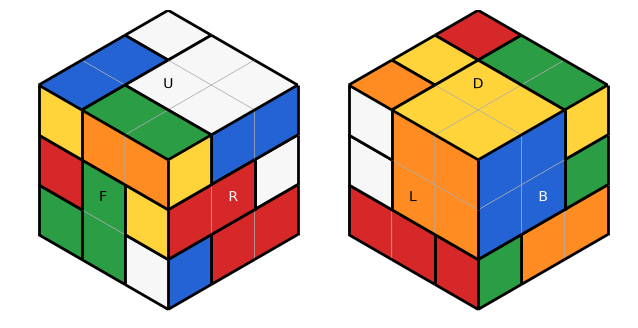

Hex ID: 051450c30ffe0011060117090d12031304061708110c0e0b021400
From solved (40 QTM): U F' U' F R' F' U F U' F R F' U' R' U F U F F U' F R F F R' F F U' R U U F' U' F F U F F U U


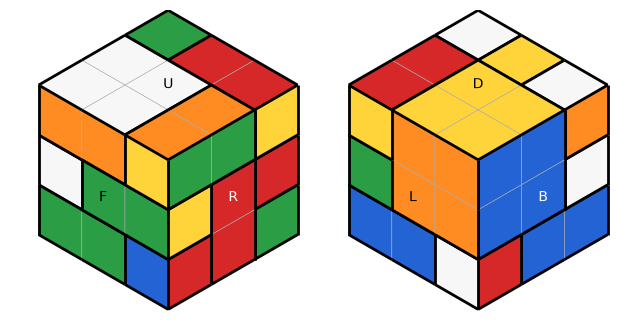

Hex ID: 051450c30ffe0017060011050d120b1704061308110c0e0b001402
From solved (40 QTM): U' R U R R F R F' R' F' U F F U' R R U' R R U U F' U' R' F R U' R U F' U' R U R' F U F F U U


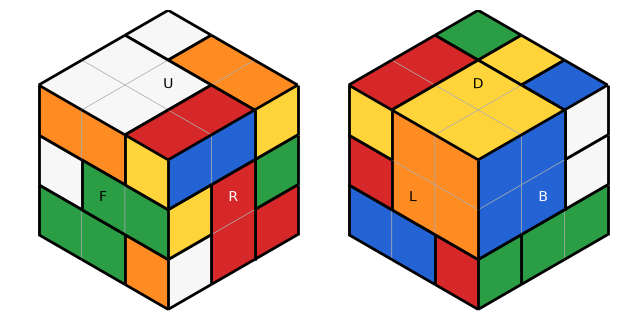

Hex ID: 051450c30ffe00161002060309120e06161204100a0c0e08031401
From solved (40 QTM): U' R U R' F R U' R' U R' F' R U F U' R' U' R R U R' F' R R F R R U F' U U R U R R U' R R U U


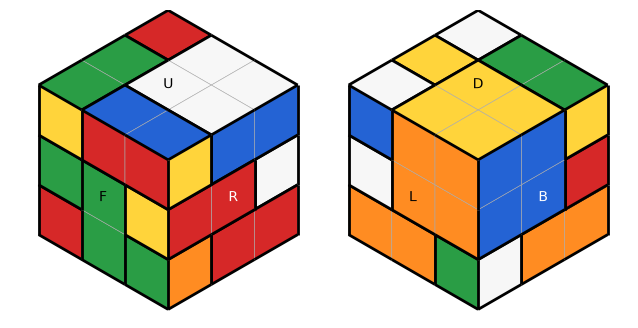

In [19]:
if counts is None:
    print("A complete colored graph is required for farthest-state examples.")
else:
    max_distance = max(counts)
    farthest_ids = [vertex for vertex, distance in enumerate(distances) if distance == max_distance]
    show = 4
    print(f"Maximum distance from solved: {max_distance} {colored_graph.metric}")
    print(f"States at maximum distance: {len(farthest_ids):,}")
    print(f"Showing {min(show, len(farthest_ids))} examples.")
    for vertex in farthest_ids[:show]:
        farthest = colored_graph[vertex]
        farthest_moves = colored_graph.shortest_path(solved, vertex)
        assert solved.apply(farthest_moves) == farthest
        print(f"Hex ID: {farthest.hex_id}")
        print(f"From solved ({max_distance} {colored_graph.metric}): {farthest_moves}")
        figure = c.draw_cubes(farthest, colors=True, views=("UFR", "BLD"))
        display(figure)
        plt.close(figure)


## Save a reproducible experiment

Puzzle records retain reference bandages and either a replay witness or validated imported colors. Graph exports retain their metric, completeness status, normalized shapes, and move actions. Isotropy exports include the exact order and total colored-state count as decimal strings, plus the reference block inventory, exact block actions, reduced generators, and legal move witnesses.

This example uses temporary files. To keep results, call `c.save_puzzle(scrambled, "experiment.json")`, `graph.save("shapes.json")`, and `analysis.save("isotropy.json")` with your own paths.


In [ ]:
with TemporaryDirectory() as directory:
    puzzle_path = Path(directory) / "Alcatraz.json"
    imported_path = Path(directory) / "Alcatraz-imported.json"
    graph_path = Path(directory) / "Alcatraz-shapes.json"
    isotropy_path = Path(directory) / "Alcatraz-isotropy.json"

    record = c.save_puzzle(scrambled, puzzle_path, name="Alcatraz experiment")
    c.save_puzzle(imported, imported_path, name="Alcatraz facelet input")
    graph.save(graph_path)
    analysis_record = analysis.save(isotropy_path)

    loaded = c.load_puzzle(puzzle_path)
    assert loaded == scrambled
    assert c.load_puzzle(imported_path) == imported
    graph_export_bytes = graph_path.stat().st_size

{
    "colored_round_trip": loaded == scrambled,
    "recorded_scramble": record["scramble"],
    "graph_export_bytes": graph_export_bytes,
    "isotropy_group_order": analysis_record["group_order"],
    "reachable_colored_states": analysis_record["colored_state_count"],
}
